# 주요 컬렉션/스큐의 평점-매출 분석

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from matplotlib.patches import Patch

In [14]:
df =pd.read_csv("ppsm_hbsm_abs_by_kwd.csv")

In [36]:
df['yr_month'] = pd.to_datetime(df['yr_month'].astype(str), format='%Y%m')

In [38]:
plot_df = df[['yr_month','sub-collection','written_avg_rating','written_12_ratio','all_avg_rating','sales_amount','sales_qty']]

In [40]:
plot_df

,yr_month,sub-collection,written_avg_rating,written_12_ratio,all_avg_rating,sales_amount,sales_qty
0,2022-01-01,ABS Easy Assembly Box Spring,3.948276,0.206897,NaN,4223520.00,32312
1,2022-02-01,ABS Easy Assembly Box Spring,4.111702,0.164894,NaN,4061965.43,31072
2,2022-03-01,ABS Easy Assembly Box Spring,4.127358,0.183962,NaN,3970434.88,27885
3,2022-04-01,ABS Easy Assembly Box Spring,3.952381,0.220238,NaN,3265957.58,23079
4,2022-05-01,ABS Easy Assembly Box Spring,4.054878,0.189024,4.506538,3879979.02,29519
...,...,...,...,...,...,...,...
196,2025-02-01,PPSM Firm Hybrid,2.571429,0.571429,4.085714,486620.09,1805
197,2025-03-01,PPSM Firm Hybrid,2.500000,0.625000,3.416667,457417.04,2081
198,2025-03-01,PPSM Firm Hybrid,2.500000,0.625000,3.416667,571675.88,2297
199,2025-03-01,PPSM Firm Hybrid,2.500000,0.625000,2.500000,457417.04,2081


In [42]:
sub_cols = plot_df['sub-collection'].unique()

In [44]:
sub_cols

array(['ABS Easy Assembly Box Spring', 'HBSM', 'PPSM Firm Hybrid'],
      dtype=object)

In [110]:
#subset = plot_df[plot_df['sub-collection']=='HBSM'].sort_values('yr_month')

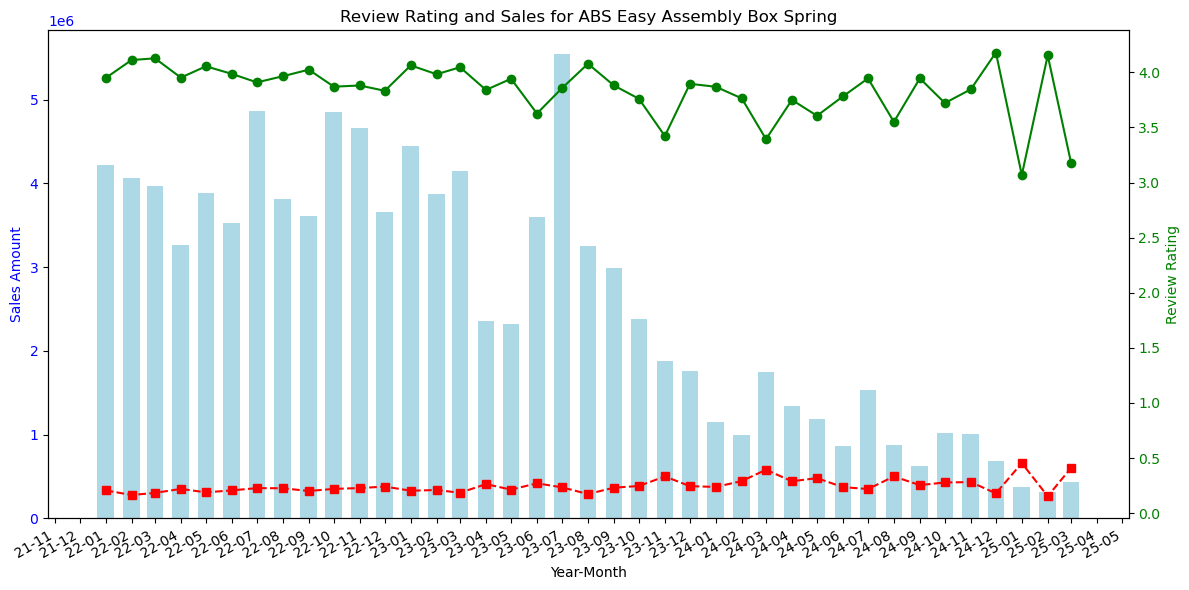

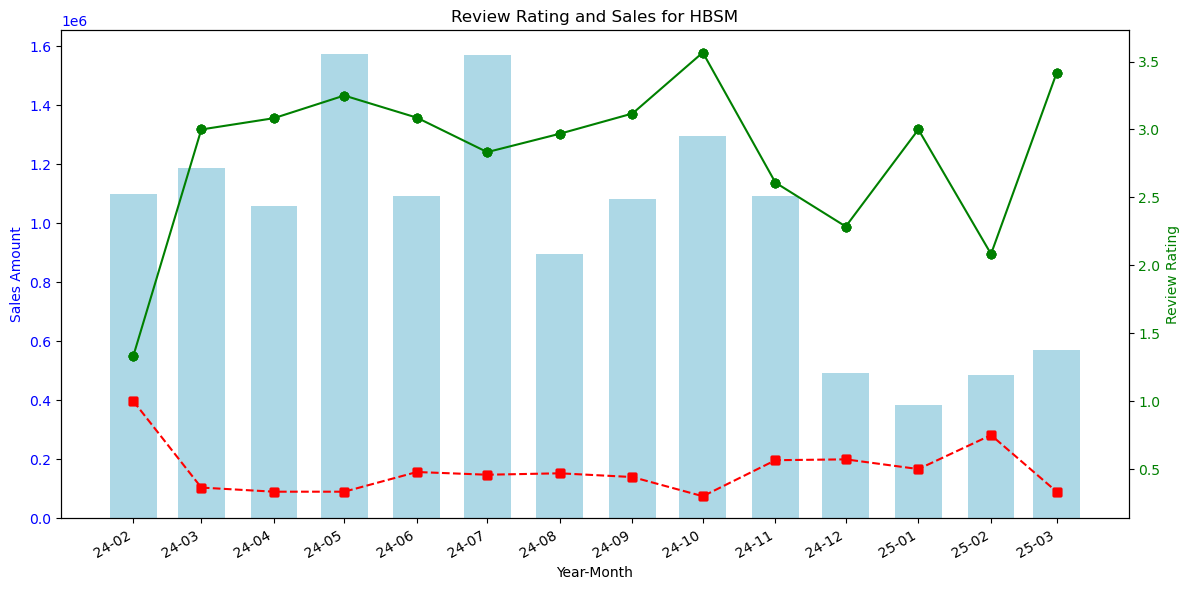

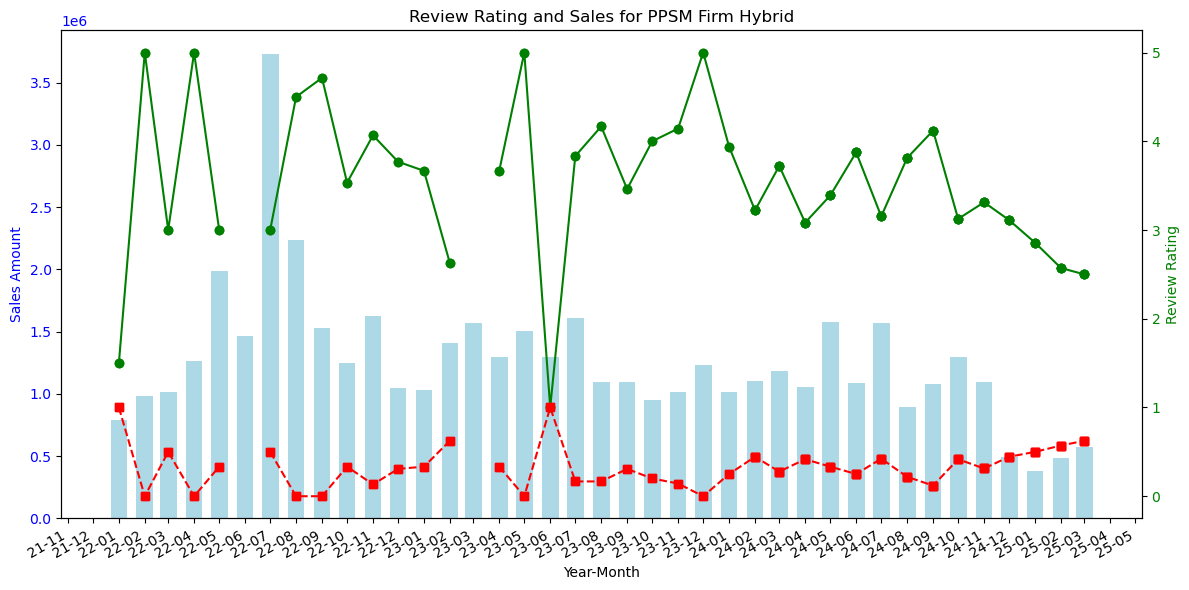

In [108]:
for cols in sub_cols:
    subset = plot_df[plot_df['sub-collection']==cols].sort_values('yr_month')

    fig, ax1 = plt.subplots(figsize=(12,6))

    # x축 모든 월 표시
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    
    # Y축 매출 (막대그래프)
    ax1.set_title(f'Review Rating and Sales for {cols}')
    ax1.set_xlabel('Year-Month')
    ax1.set_ylabel('Sales Amount', color='blue')
    ax1.bar(subset['yr_month'], subset['sales_amount'], width=20, color='lightblue', label='Sales Amount')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Y축 평점
    ax2 = ax1.twinx()
    ax2.set_ylabel('Review Rating', color='green')
    ax2.plot(subset['yr_month'], subset['written_avg_rating'], marker='o', color='green', label='Average Rating')
    ax2.plot(subset['yr_month'], subset['written_12_ratio'], marker='s', linestyle='--', color='red', label='Low Rating Ratio') 
    #ax2.plot(subset['yr_month'], subset['all_avg_rating'], marker='^', color='purple', label='All Avg Rating') 

    ax2.tick_params(axis='y', labelcolor='green')

    # 범례 추가
    #bar_patch = Patch(color='lightblue', label='Sales Amount')
    #handles = [bar_patch, line1, line2]
    #labels = ['Sales Amount','Written Average Rating', 'Written 12 Ratio']
    #ax2.legend(handles, labels, loc='upper left')

    fig.autofmt_xdate() # x축 레이블 자동 회전
    fig.tight_layout()
    plt.show()
    